# DL061 对抗生成与博弈训练

从新内核顺序运行。这个Notebook会真实训练三个基准和一个压力运行，不依赖隐藏变量或只展示缓存输出。教材固定结果位于outputs；本次重跑写入notebook_outputs。

In [1]:
from pathlib import Path
import sys, json, numpy as np, torch
import experiment as e
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'unit':Path.cwd().name})
torch.set_num_threads(1)

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '061'}


## 1 先手算损失
真假两组均值相加，所以D=0.5时损失为2log2。G的非饱和损失则为log2。

In [2]:
p=np.array([.8,.6]); q=np.array([.2,.4])
print('D batch loss:',-np.log(p).mean()-np.log(1-q).mean())
print('D .5 reference:',2*np.log(2),'G .5 reference:',np.log(2))

D batch loss: 0.7339691750802004
D .5 reference: 1.3862943611198906 G .5 reference: 0.6931471805599453


## 2 行为测试
检查更新隔离、指标分母、极端logit和可复现性。测试通过不保证收敛，只排除已覆盖的程序错误。

In [3]:
import unittest, test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=1).run(suite)
if not result.wasSuccessful(): raise RuntimeError('unit tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 13 tests in 1.109s

OK


## 3 原创训练数据与评价器负对照
八种模式标签只用于评价，不进入GAN训练。常数样本是人为构造，不能作为真实训练坍塌的证据。

In [4]:
x,labels=e.make_data()
print('data:',x.shape,'reference metric:',e.mode_metrics(x))
constant=np.repeat(e.centers()[:1],4096,axis=0)
print('FORCED metric control:',e.mode_metrics(constant))

data: (4096, 2) reference metric: {'coverage': 8, 'valid_fraction': 1.0, 'counts': [544, 483, 536, 509, 512, 493, 508, 511], 'fractions': [0.1328125, 0.117919921875, 0.130859375, 0.124267578125, 0.125, 0.120361328125, 0.1240234375, 0.124755859375], 'conditional_max_mass': 0.1328125, 'conditional_entropy': 2.0787693279622084, 'mean_nearest_distance': 0.10032623261213303}
FORCED metric control: {'coverage': 1, 'valid_fraction': 1.0, 'counts': [4096, 0, 0, 0, 0, 0, 0, 0], 'fractions': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'conditional_max_mass': 1.0, 'conditional_entropy': -0.0, 'mean_nearest_distance': 0.0}


## 4 实际重新训练
基准3000轮、三个种子；压力2200轮、种子17。每100轮保存固定噪声的输出，评估随机序列与训练分开。

In [5]:
results=e.main(Path('notebook_outputs'),steps=3000,stress_steps=2200)
for run in results['runs']: print(run['seed'],run['final']['coverage'],run['final']['valid_fraction'])

baseline 11 {'step': 3000, 'd_loss': 1.2690870761871338, 'g_loss': 0.8065548539161682, 'd_real_mean': 0.536888599395752, 'd_fake_mean': 0.4643416106700897, 'coverage': 8, 'valid_fraction': 0.624267578125, 'counts': [259, 428, 347, 199, 325, 412, 430, 157], 'fractions': [0.063232421875, 0.1044921875, 0.084716796875, 0.048583984375, 0.079345703125, 0.1005859375, 0.10498046875, 0.038330078125], 'conditional_max_mass': 0.16816581931951505, 'conditional_entropy': 2.0283382780618364, 'mean_nearest_distance': 0.3052704930305481}


baseline 23 {'step': 3000, 'd_loss': 1.2713156938552856, 'g_loss': 0.7937169075012207, 'd_real_mean': 0.5343716740608215, 'd_fake_mean': 0.4653557240962982, 'coverage': 8, 'valid_fraction': 0.6748046875, 'counts': [388, 137, 458, 362, 476, 325, 207, 411], 'fractions': [0.0947265625, 0.033447265625, 0.11181640625, 0.08837890625, 0.1162109375, 0.079345703125, 0.050537109375, 0.100341796875], 'conditional_max_mass': 0.17221418234442837, 'conditional_entropy': 2.020749150932165, 'mean_nearest_distance': 0.26988330483436584}


baseline 37 {'step': 3000, 'd_loss': 1.259467363357544, 'g_loss': 0.8133335709571838, 'd_real_mean': 0.5369536280632019, 'd_fake_mean': 0.4671528935432434, 'coverage': 8, 'valid_fraction': 0.604248046875, 'counts': [345, 204, 385, 389, 347, 246, 199, 360], 'fractions': [0.084228515625, 0.0498046875, 0.093994140625, 0.094970703125, 0.084716796875, 0.06005859375, 0.048583984375, 0.087890625], 'conditional_max_mass': 0.15717171717171718, 'conditional_entropy': 2.048685485543573, 'mean_nearest_distance': 0.31739333271980286}


stress {'step': 800, 'd_loss': 1.3861031532287598, 'g_loss': 0.6959060430526733, 'd_real_mean': 0.499287486076355, 'd_fake_mean': 0.49841874837875366, 'coverage': 1, 'valid_fraction': 1.0, 'counts': [0, 0, 0, 0, 0, 4096, 0, 0], 'fractions': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], 'conditional_max_mass': 1.0, 'conditional_entropy': -0.0, 'mean_nearest_distance': 0.11411339044570923}


11 8 0.624267578125
23 8 0.6748046875
37 8 0.604248046875


## 5 区分失败快照与最终状态
诊断规则公开选择有效比例至少0.5的低覆盖快照；最终状态单独报告。

In [6]:
s=results['stress']
print('diagnostic:',s['diagnostic'])
print('final:',s['final'])
print('configuration:',s['lr_g'],s['lr_d'],s['g_steps_per_d'])

diagnostic: {'step': 800, 'd_loss': 1.3861031532287598, 'g_loss': 0.6959060430526733, 'd_real_mean': 0.499287486076355, 'd_fake_mean': 0.49841874837875366, 'coverage': 1, 'valid_fraction': 1.0, 'counts': [0, 0, 0, 0, 0, 4096, 0, 0], 'fractions': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], 'conditional_max_mass': 1.0, 'conditional_entropy': -0.0, 'mean_nearest_distance': 0.11411339044570923}
final: {'step': 2200, 'd_loss': 1.3509083986282349, 'g_loss': 0.720653772354126, 'd_real_mean': 0.5046552419662476, 'd_fake_mean': 0.4864359498023987, 'coverage': 0, 'valid_fraction': 0.0, 'counts': [0, 0, 0, 0, 0, 0, 0, 0], 'fractions': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'conditional_max_mass': 0.0, 'conditional_entropy': -0.0, 'mean_nearest_distance': 0.5746781826019287}
configuration: 0.002 0.0001 5


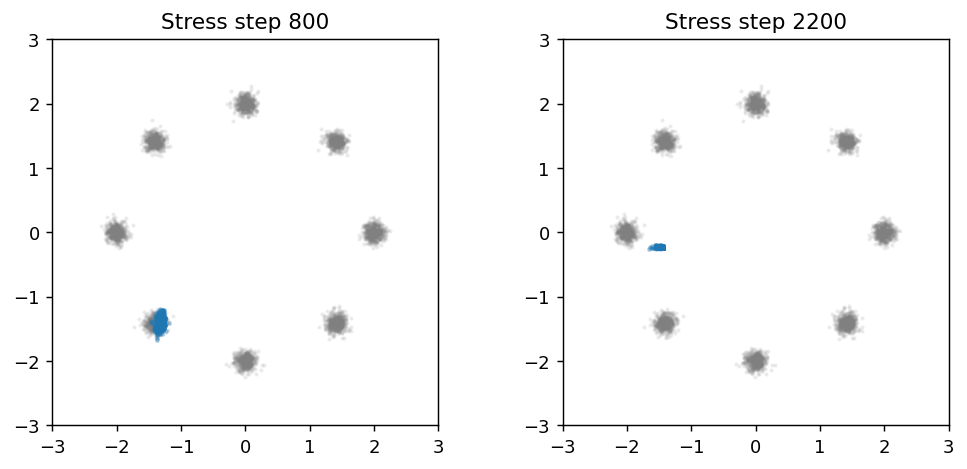

In [7]:
import matplotlib.pyplot as plt
samples=np.load('notebook_outputs/stress_seed17_samples.npz')
fig,axes=plt.subplots(1,2,figsize=(8,3.7))
for ax,step in zip(axes,[s['diagnostic']['step'],s['steps']]):
    a=samples[str(step)]
    ax.scatter(x[:,0],x[:,1],s=2,alpha=.1,color='gray')
    ax.scatter(a[:,0],a[:,1],s=3,alpha=.3)
    ax.set(title=f'Stress step {step}',xlim=(-3,3),ylim=(-3,3),aspect='equal')
fig.tight_layout();show(fig);plt.close(fig)

## 6 理论的数值核对
使用两格分布计算JS与理想目标。它不等于实际非饱和训练日志中的G损失。

In [8]:
p=np.array([.5,.5]);q=np.array([1.,0.]);m=(p+q)/2
klp=(p*np.log(p/m)).sum();klq=np.log(1/m[0]);js=(klp+klq)/2
print({'KL_p_m':klp,'KL_q_m':klq,'JS':js,'ideal_V':-np.log(4)+2*js})

{'KL_p_m': np.float64(0.14384103622589042), 'KL_q_m': np.float64(0.28768207245178085), 'JS': np.float64(0.21576155433883565), 'ideal_V': np.float64(-0.9547712524422193)}


## 7 写出可支持的结论
请解释8/8覆盖为何不足以证明分布匹配；0.5判别概率为何不足以证明成功；压力配置为何不能单独归因某一个超参数。完整推导、实验要求与详细答案见同目录三份PDF。